# TS5: Estimación espectral: Ancho de banda de señales reales

## 1. Objetivo

En este trabajo se analizarán tres tipos de señales reales:

- Electrocardiograma (ECG)
- Pletismografía (PPG)
- Audio

Para cada señal se realizará una estimación de la densidad espectral de potencia (PSD) utilizando el método de Welch.

A partir de la PSD se estimará además el ancho de banda de cada señal empleando un criterio común, con el objetivo de comparar señales de distinta naturaleza.

Como criterio de ancho de banda se utilizará la frecuencia por debajo de la cual se concentra el 99 % de la potencia espectral total.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.io import loadmat, wavfile

## Estimación de la densidad espectral de potencia

Para estimar la densidad espectral de potencia se utilizará el método de Welch.

El periodograma convencional de una señal de $N$ muestras puede expresarse como

$$
\hat S_{xx}(f)=\frac{1}{N}|X(f)|^2
$$

y presenta una varianza elevada.

El método de Welch reduce dicha varianza dividiendo la señal en segmentos, aplicando una ventana a cada segmento y promediando los periodogramas obtenidos.

En este trabajo se utilizará una ventana Hann con 50 % de solapamiento.

Este procedimiento introduce un compromiso entre:

- resolución espectral;
- reducción del desparramo espectral;
- varianza de la estimación.

Una mayor longitud de segmento mejora la resolución en frecuencia, mientras que una mayor cantidad de segmentos permite realizar un mayor promediado y disminuir la varianza.

In [46]:
def calcular_psd_welch(x, fs, nperseg, nombre='Señal'):
    x = np.asarray(x).squeeze()

    # Eliminación de componente continua
    x = x - np.mean(x)

    # Evitar que nperseg sea mayor que la señal
    nperseg = min(nperseg, len(x))

    f, Pxx = signal.welch(
        x,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend='constant',
        scaling='density'
    )

    return f, Pxx

## Criterio utilizado para estimar el ancho de banda

Las señales analizadas no poseen necesariamente un límite espectral abrupto, por lo que se utilizará un criterio basado en una proporción alta de la potencia espectral acumulada.

Para las señales fisiológicas, ECG y PPG, se las considerará aproximadamente pasabajo. En estos casos se define el ancho de banda como la frecuencia $f_{99}$ por debajo de la cual se concentra el 99 % de la potencia:

$$
\frac{
\int_0^{f_{99}} S_{xx}(f)\,df
}{
\int_0^{f_s/2} S_{xx}(f)\,df
}
=0.99
$$

y se toma

$$
BW = f_{99}
$$

Para las señales de audio se las considerará pasabanda. En este caso se buscarán dos frecuencias, $f_L$ y $f_H$, entre las cuales se concentre el 99 % de la potencia total:

$$
BW = f_H - f_L
$$

Se distribuirá el 1 % restante en partes iguales en ambos extremos del espectro.

In [47]:
def ancho_banda_potencia(f, Pxx, porcentaje=0.99):

    potencia_acumulada = np.cumsum(Pxx)
    potencia_acumulada = potencia_acumulada / potencia_acumulada[-1]

    idx = np.searchsorted(
        potencia_acumulada,
        porcentaje
    )

    return f[idx], potencia_acumulada

def ancho_banda_pasobanda(f, Pxx, porcentaje=0.99):

    potencia_acumulada = np.cumsum(Pxx)
    potencia_acumulada = potencia_acumulada / potencia_acumulada[-1]

    resto = 1 - porcentaje

    limite_inf = resto / 2
    limite_sup = 1 - resto / 2

    idx_inf = np.searchsorted(potencia_acumulada, limite_inf)
    idx_sup = np.searchsorted(potencia_acumulada, limite_sup)

    f_low = f[idx_inf]
    f_high = f[idx_sup]

    bw = f_high - f_low

    return f_low, f_high, bw, potencia_acumulada

In [48]:
def graficar_psd_y_bw(f, Pxx, bw, potencia_acumulada, nombre):
    
    Pxx_db = 10 * np.log10(Pxx + np.finfo(float).eps)

    plt.figure(figsize=(10, 4))
    plt.plot(f, Pxx_db)
    plt.axvline(
        bw,
        linestyle='--',
        label=f'BW 99% = {bw:.2f} Hz'
    )

    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD [dB/Hz]')
    plt.title(f'PSD mediante Welch — {nombre}')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(f, potencia_acumulada)
    plt.axhline(0.99, linestyle='--')
    plt.axvline(
        bw,
        linestyle='--',
        label=f'f99 = {bw:.2f} Hz'
    )

    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Potencia acumulada normalizada')
    plt.title(f'Potencia espectral acumulada — {nombre}')
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)
    plt.show()

def graficar_psd_audio(f, Pxx, f_low, f_high, nombre):

    Pxx_db = 10 * np.log10(Pxx + np.finfo(float).eps)

    plt.figure(figsize=(10, 4))
    plt.plot(f, Pxx_db)

    plt.axvline(
        f_low,
        linestyle='--',
        label=f'fL = {f_low:.2f} Hz'
    )

    plt.axvline(
        f_high,
        linestyle='--',
        label=f'fH = {f_high:.2f} Hz'
    )

    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD [u.a.^2/Hz]')
    plt.title(f'PSD mediante Welch — {nombre}')
    plt.legend()
    plt.grid(True)
    plt.show()

# 1. Electrocardiograma (ECG)

El registro corresponde a una señal electrocardiográfica obtenida durante una prueba de esfuerzo.

La frecuencia de muestreo del registro es

$$
f_s = 1000\ \text{Hz}
$$

Antes de realizar la estimación espectral se elimina el valor medio de la señal para evitar que la componente continua domine la representación del espectro.

Cantidad de muestras: 1129116
Duración: 1129.116 s


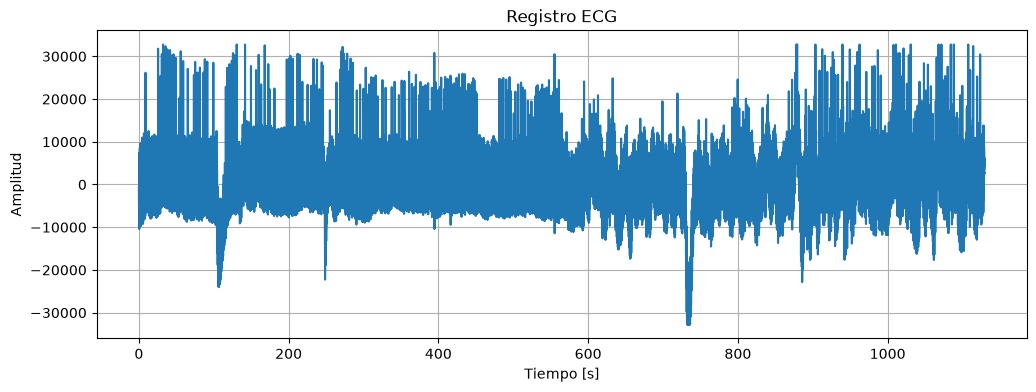

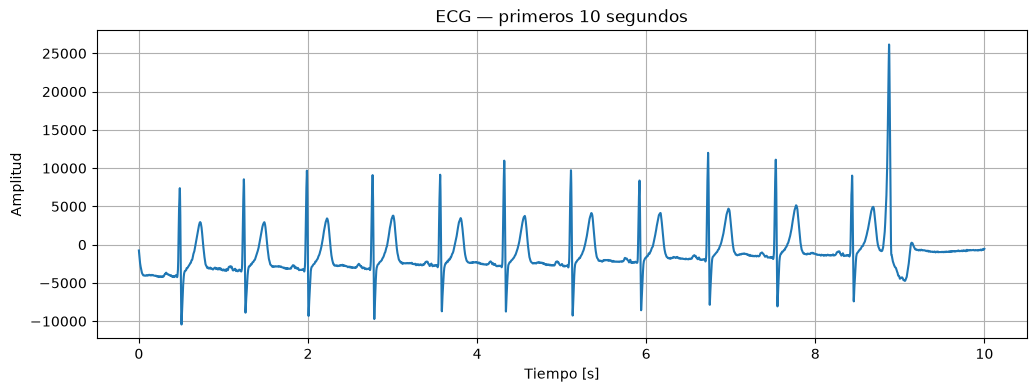

Resolución espectral aproximada: 0.244 Hz
Ancho de banda: 31.01 Hz


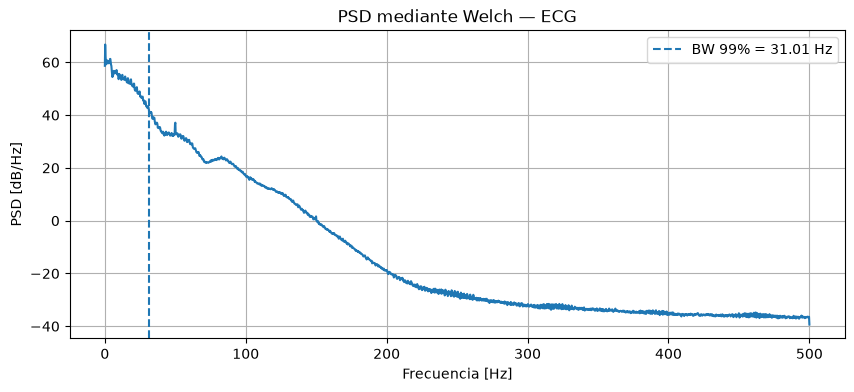

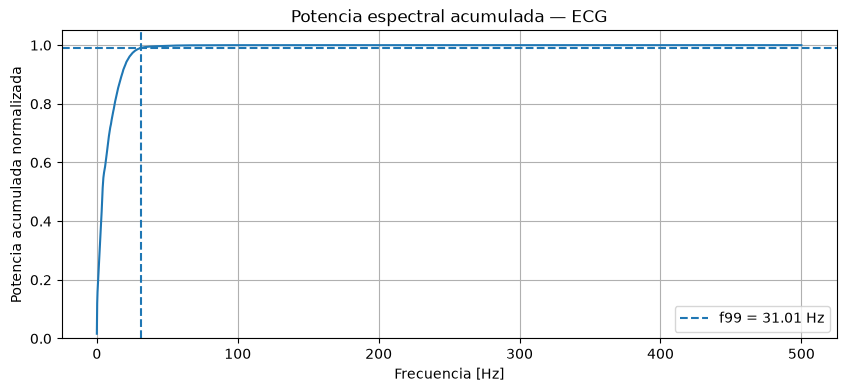

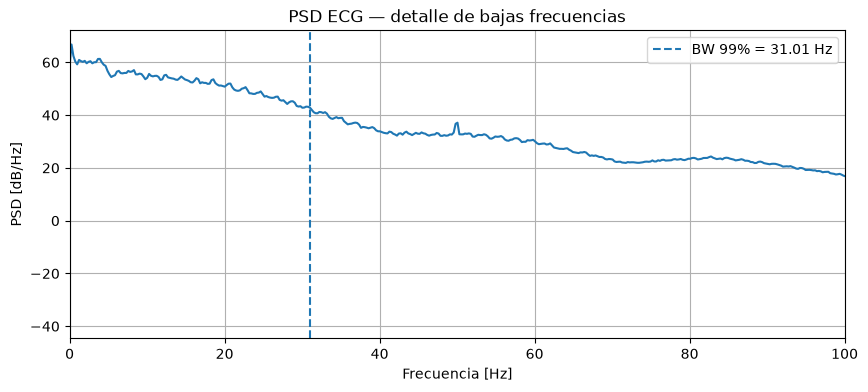

In [49]:
ecg_mat = loadmat('ECG_TP4.mat')

fs_ecg = 1000

print('Cantidad de muestras:', len(ecg))
print('Duración:', len(ecg) / fs_ecg, 's')

t_ecg = np.arange(len(ecg)) / fs_ecg

plt.figure(figsize=(12, 4))
plt.plot(t_ecg, ecg)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Registro ECG')
plt.grid(True)
plt.show()

duracion_vista = 10

N_vista = int(duracion_vista * fs_ecg)

plt.figure(figsize=(12, 4))
plt.plot(t_ecg[:N_vista], ecg[:N_vista])

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('ECG — primeros 10 segundos')
plt.grid(True)
plt.show()

nperseg_ecg = 4096

f_ecg, Pxx_ecg = calcular_psd_welch(ecg, fs_ecg, nperseg_ecg, nombre='ECG')

bw_ecg, acum_ecg = ancho_banda_potencia(f_ecg, Pxx_ecg, porcentaje=0.99)

print(f'Resolución espectral aproximada: 'f'{fs_ecg/nperseg_ecg:.3f} Hz')

print(f'Ancho de banda: 'f'{bw_ecg:.2f} Hz')

graficar_psd_y_bw(f_ecg, Pxx_ecg, bw_ecg, acum_ecg, 'ECG')

plt.figure(figsize=(10, 4))
plt.plot(f_ecg, 10*np.log10(Pxx_ecg + np.finfo(float).eps))
plt.xlim(0, 100)
plt.axvline(bw_ecg, linestyle='--', label=f'BW 99% = {bw_ecg:.2f} Hz')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.title('PSD ECG — detalle de bajas frecuencias')
plt.legend()
plt.grid(True)
plt.show()

### Análisis del ECG

La PSD del ECG presenta la mayor concentración de potencia en bajas frecuencias, comportamiento esperable para una señal electrocardiográfica.

Se observan componentes asociadas a la periodicidad cardíaca y a la morfología de los complejos presentes en la señal.

Mediante el criterio de potencia acumulada se obtuvo un ancho de banda de aproximadamente

$$
BW_{99} = \text{31 Hz}
$$

La utilización de Welch permite reducir la variabilidad de la estimación respecto de un periodograma convencional, facilitando la identificación de la región espectral donde se concentra la potencia de la señal.

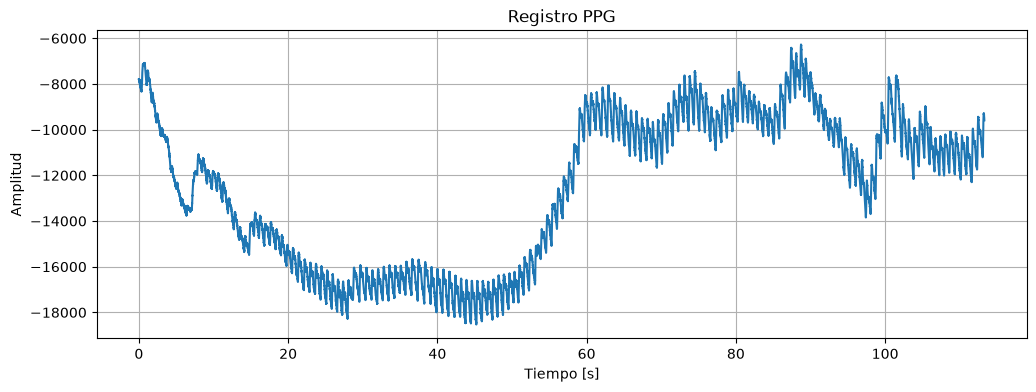

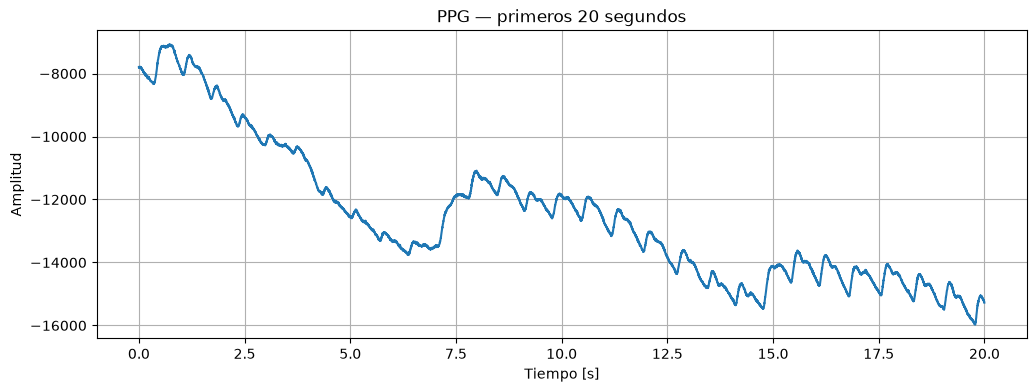

Resolución espectral aproximada: 0.195 Hz
Ancho de banda estimado (99%): 4.49 Hz


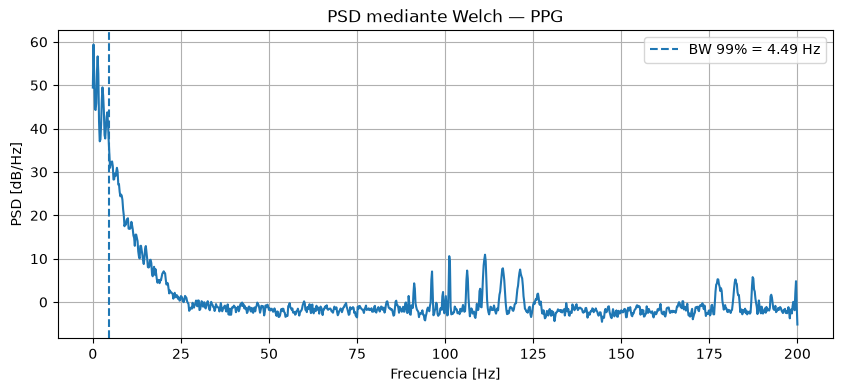

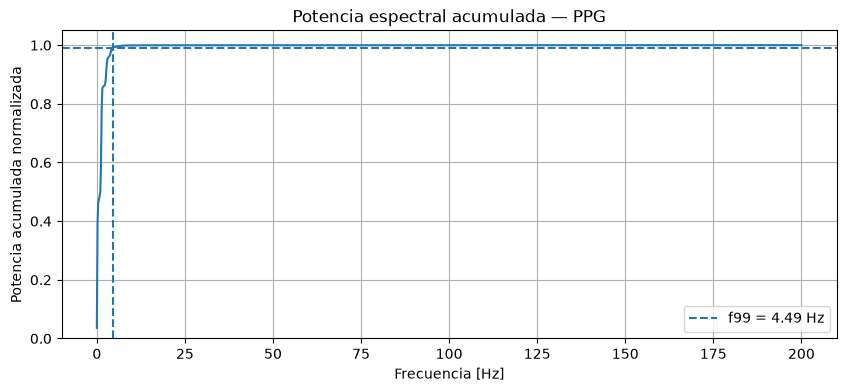

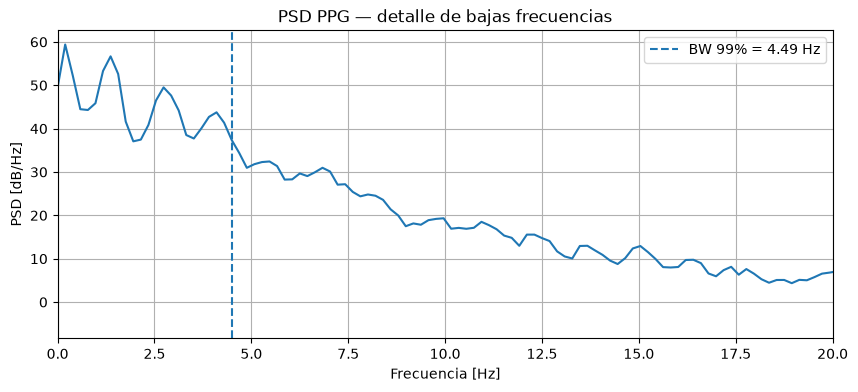

In [50]:
fs_ppg = 400

ppg = pd.read_csv('PPG.csv')

t_ppg = np.arange(len(ppg_signal)) / fs_ppg

plt.figure(figsize=(12, 4))
plt.plot(t_ppg, ppg_signal)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Registro PPG')
plt.grid(True)
plt.show()

duracion_vista = 20

N_vista = int(duracion_vista * fs_ppg)

plt.figure(figsize=(12, 4))
plt.plot(t_ppg[:N_vista], ppg_signal[:N_vista])

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('PPG — primeros 20 segundos')
plt.grid(True)
plt.show()

nperseg_ppg = 2048

f_ppg, Pxx_ppg = calcular_psd_welch(ppg_signal, fs_ppg, nperseg_ppg, nombre='PPG')
bw_ppg, acum_ppg = ancho_banda_potencia(f_ppg, Pxx_ppg, porcentaje=0.99)

print(f'Resolución espectral aproximada: 'f'{fs_ppg/nperseg_ppg:.3f} Hz')
print(f'Ancho de banda estimado (99%): 'f'{bw_ppg:.2f} Hz')

graficar_psd_y_bw(f_ppg, Pxx_ppg, bw_ppg, acum_ppg, 'PPG')

plt.figure(figsize=(10, 4))
plt.plot(f_ppg, 10*np.log10(Pxx_ppg + np.finfo(float).eps))
plt.xlim(0, 20)
plt.axvline(bw_ppg, linestyle='--', label=f'BW 99% = {bw_ppg:.2f} Hz')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.title('PSD PPG — detalle de bajas frecuencias')
plt.legend()
plt.grid(True)
plt.show()



la cucaracha.wav: fs = 48000 Hz, BW99 = 1031.25 Hz


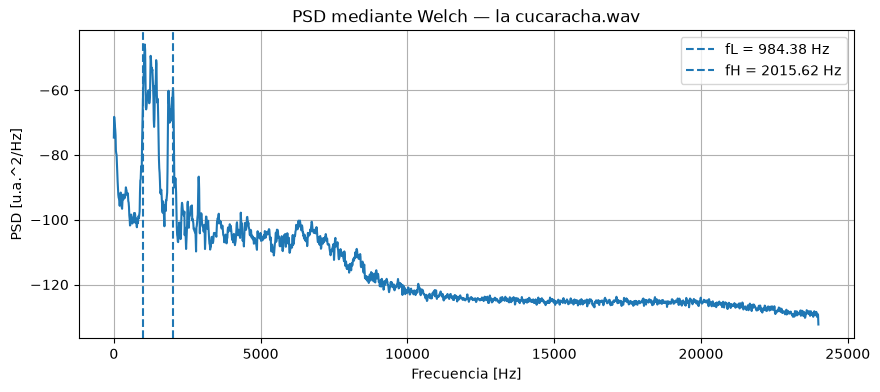

prueba psd.wav: fs = 48000 Hz, BW99 = 3914.06 Hz


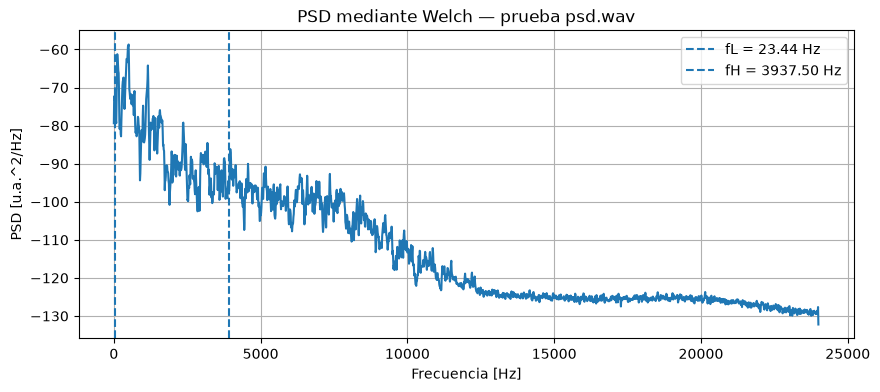

silbido.wav: fs = 48000 Hz, BW99 = 4054.69 Hz


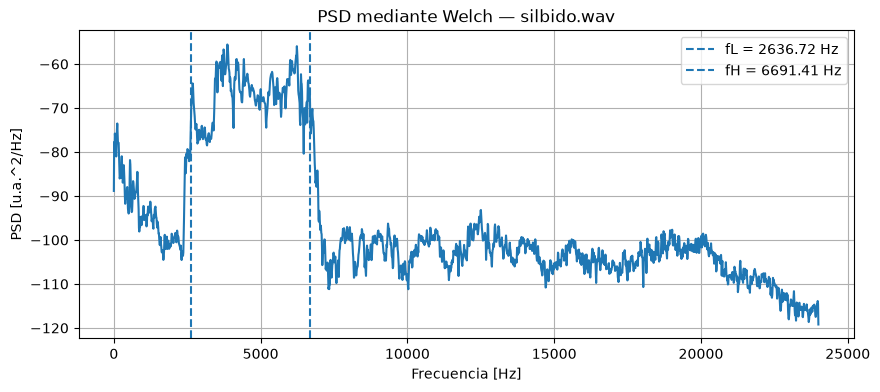

In [52]:
audios = [
    'la cucaracha.wav',
    'prueba psd.wav',
    'silbido.wav'
]

resultados_audio = []

for archivo in audios:

    fs_audio, audio = wavfile.read(archivo)

    audio = audio.astype(float)

    f_audio, Pxx_audio = calcular_psd_welch(audio, fs_audio, nperseg=4096, nombre=archivo)

    f_low, f_high, bw_audio, acum_audio = ancho_banda_pasobanda(f_audio, Pxx_audio, porcentaje=0.99)

    resultados_audio.append({
        'Señal': archivo,
        'Tipo': 'Pasabanda',
        'fs [Hz]': fs_audio,
        'Método': 'Welch',
        'Ventana': 'Hann',
        'fL [Hz]': f_low,
        'fH [Hz]': f_high,
        'BW [Hz]': bw_audio
    })

    print(f'{archivo}: 'f'fs = {fs_audio} Hz, 'f'BW99 = {bw_audio:.2f} Hz')

    graficar_psd_audio(
        f_audio,
        Pxx_audio,
        f_low,
        f_high,
        archivo
    )

In [53]:
resultados = pd.DataFrame([
    {
        'Señal': 'ECG',
        'fs [Hz]': fs_ecg,
        'Método': 'Welch',
        'Ventana': 'Hann',
        'BW 99% [Hz]': bw_ecg
    },
    {
        'Señal': 'PPG',
        'fs [Hz]': fs_ppg,
        'Método': 'Welch',
        'Ventana': 'Hann',
        'BW 99% [Hz]': bw_ppg
    },
        {
        'Señal': 'La cucaracha',
        'fs [Hz]': '48000',
        'Método': 'Welch',
        'Ventana': 'Hann',
        'BW 99% [Hz]': 'fL = 984.38; fH = 2015.62'
    },
    {
        'Señal': 'Prueba PSD',
        'fs [Hz]': '48000',
        'Método': 'Welch',
        'Ventana': 'Hann',
        'BW 99% [Hz]': 'fL = 23.44; fH = 3937.50'
    },
    {
        'Señal': 'Silbido',
        'fs [Hz]': '48000',
        'Método': 'Welch',
        'Ventana': 'Hann',
        'BW 99% [Hz]': 'fL = 2326.72; fH = 6691,41'
    }
])

resultados

,Señal,fs [Hz],Método,Ventana,BW 99% [Hz]
0,ECG,1000,Welch,Hann,31.005859
1,PPG,400,Welch,Hann,4.492188
2,La cucaracha,48000,Welch,Hann,fL = 984.38; fH = 2015.62
3,Prueba PSD,48000,Welch,Hann,fL = 23.44; fH = 3937.50
4,Silbido,48000,Welch,Hann,"fL = 2326.72; fH = 6691,41"


# Conclusiones

Se estimó la densidad espectral de potencia de registros reales de ECG, PPG y audio mediante el método de Welch.

La aplicación de una ventana Hann y el promedio de segmentos parcialmente solapados permitió obtener estimaciones espectrales con menor varianza que un periodograma convencional.

Para comparar cuantitativamente señales de distinta naturaleza se definió el ancho de banda como la frecuencia que contiene el 99 % de la potencia espectral.

Los resultados muestran diferencias importantes entre las señales fisiológicas y las señales de audio, tanto en la distribución de potencia como en su ancho de banda.

La elección de los parámetros de Welch implica un compromiso entre resolución espectral y varianza: segmentos largos proporcionan una mejor resolución en frecuencia, mientras que segmentos más cortos permiten un mayor número de promedios y, por lo tanto, una estimación más estable.